# Fixing Mercator ORCA12 vertical velocities

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np

In [2]:
mesh_path = "/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc"
W_path = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/W_1993-01c.nc"
SSH_path = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/SSH_1993-01c.nc"

## Load Mesh file

Ensure there's integer coordinates for three array dims, remove singleton `t` dimension.

In [3]:
ds_mesh = xr.open_dataset(mesh_path, chunks={})
ds_mesh = ds_mesh.assign_coords(x=np.arange(ds_mesh.sizes["x"]))
ds_mesh = ds_mesh.assign_coords(y=np.arange(ds_mesh.sizes["y"]))
ds_mesh = ds_mesh.assign_coords(z=np.arange(ds_mesh.sizes["z"]))
ds_mesh = ds_mesh.squeeze()
ds_mesh

<xarray.Dataset>
Dimensions:       (y: 499, x: 1260, z: 50)
Coordinates:
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * z             (z) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
Data variables: (12/13)
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lev       (z) float32 dask.array<chunksize=(50,), meta=np.ndarray>
    time_counter  float64 dask.array<chunksize=(), meta=np.ndarray>
    mbathy        (y, x) int16 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    deptht        (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    ...            ...
    e3t_ps        (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    e3w_ps        (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    gdept_0       (z) float64 dask.array<chunksize=(50,), meta=np.ndarray>
    gdepw_0       (z) float64 dask.array<chunksize=(50,), meta=np.ndarray>
    e3t_0         (z) float64 dask.array<chunksize=(50,), meta=np.ndarray>
    e3w_0         (z) float64 dask.array<chunksize=(50,), meta=np.ndarray>
Attributes:
    file_name:            mesh_zgr.nc
    TimeStamp:            03/02/2016 10:24:41 -0000
    Unlimited_Dimension:  t
    history:              Wed Nov  5 17:28:38 2025: ncrename -v hdept,deptht ...
    NCO:                  netCDF Operators version 5.0.6 (Homepage = http://n...

## Construct W depth for each water filled cell

`mbathy` is the number of grid cells filled with water in the vertical. And we have partially filled bottom cells. So we sum over the first `mbathy-1` values in `e3t_0` and then add `e3t_ps` for the height of the last cell.

In [4]:
e3t_full = xr.where(
    (ds_mesh.z + 1) <= (ds_mesh.mbathy - 1),  # wet cells above bottom cells
    ds_mesh.e3t_0,  # fill with basin wide e3t for level,
    ds_mesh.e3t_ps,  # add partial cell height otherwise
).where((ds_mesh.z + 1) <= ds_mesh.mbathy)  # remove all non-wet cells below
e3t_full

<xarray.DataArray (z: 50, y: 499, x: 1260)>
dask.array<where, shape=(50, 499, 1260), dtype=float64, chunksize=(50, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * z        (z) int64 0 1 2 3 4 5 6 7 8 9 10 ... 40 41 42 43 44 45 46 47 48 49
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 1253 1254 1255 1256 1257 1258 1259
  * y        (y) int64 0 1 2 3 4 5 6 7 8 ... 490 491 492 493 494 495 496 497 498

Have a look at one section of cell heights:

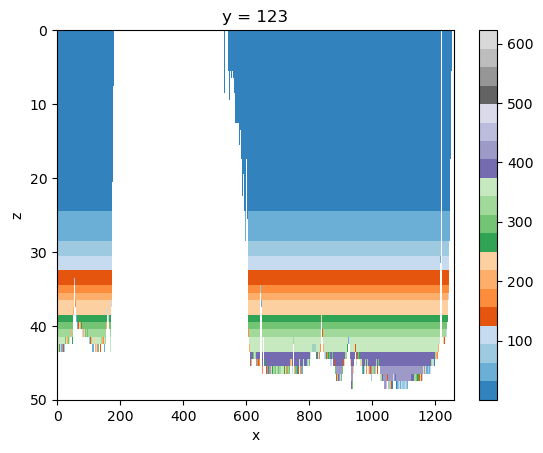

In [5]:
e3t_full.isel(y=123).plot(ylim=(50, 0), cmap="tab20c")

W depths (top of cell) as vertical sum of the `e3t` (including the partially filled last cell above the bottom).
Then rename the _dimension_ `z` coming from the mesh file to `depthw` which we'll need to align with the W file later.

In [6]:
depthw_ps = e3t_full.cumsum("z").where((ds_mesh.z + 1) <= ds_mesh.mbathy)
depthw_ps = depthw_ps.shift(z=1).fillna(0.0)
depthw_ps = depthw_ps.where(ds_mesh.z <= ds_mesh.mbathy)
depthw_ps = depthw_ps.rename({"z": "depthw"}).drop("depthw")
depthw_ps

<xarray.DataArray (depthw: 50, y: 499, x: 1260)>
dask.array<where, shape=(50, 499, 1260), dtype=float64, chunksize=(50, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 1253 1254 1255 1256 1257 1258 1259
  * y        (y) int64 0 1 2 3 4 5 6 7 8 ... 490 491 492 493 494 495 496 497 498
Dimensions without coordinates: depthw

## Calc height of water colum (relto $\eta=0$)

In [7]:
H_bottom = e3t_full.sum("z")
H_bottom

<xarray.DataArray (y: 499, x: 1260)>
dask.array<sum-aggregate, shape=(499, 1260), dtype=float64, chunksize=(499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 0 1 2 3 4 5 6 7 ... 1253 1254 1255 1256 1257 1258 1259
  * y        (y) int64 0 1 2 3 4 5 6 7 8 ... 490 491 492 493 494 495 496 497 498

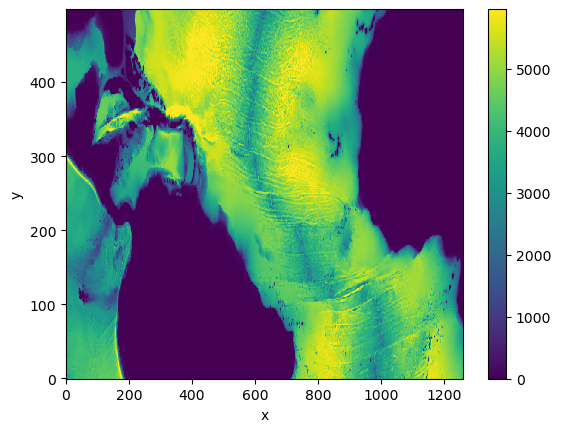

In [8]:
H_bottom.plot()

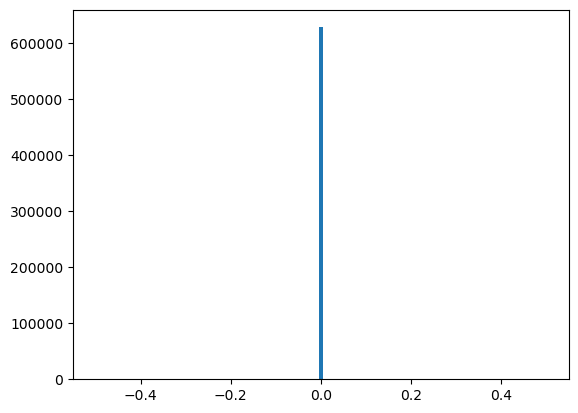

In [9]:
# should be all zeros then:
(depthw_ps.max("depthw") - H_bottom).plot.hist(bins=101);

## Load W file

Ensure x and y dimensional coordinate, and build in H and correct (accounting for partial cell height) depthw:

In [10]:
ds_W = xr.open_dataset(W_path, chunks={"time_counter": 1})
ds_W = ds_W.assign_coords(x=np.arange(ds_W.sizes["x"]))
ds_W = ds_W.assign_coords(y=np.arange(ds_W.sizes["y"]))
ds_W = ds_W.assign_coords(z=-depthw_ps, H=H_bottom)
ds_W

<xarray.Dataset>
Dimensions:       (time_counter: 31, y: 499, x: 1260, depthw: 50)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * depthw        (depthw) float32 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
    z             (depthw, y, x) float64 dask.array<chunksize=(50, 499, 1260), meta=np.ndarray>
    H             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 dask.array<chunksize=(1, 50, 499, 1260), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.2.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Fri Nov 07 00:26:13 2025: cdo setmissval,nan W_1993-01.nc /...
    CDO:          Climate Data Operators version 2.2.2 (https://mpimet.mpg.de...

## Load SSH (we need $\eta$)

In [11]:
ds_SSH = xr.open_dataset(SSH_path, chunks={"time_counter": 1})
ds_SSH = ds_SSH.assign_coords(x=np.arange(ds_SSH.sizes["x"]))
ds_SSH = ds_SSH.assign_coords(y=np.arange(ds_SSH.sizes["y"]))
ds_SSH

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/xarray/conventions.py:427: SerializationWarning: variable 'sossheig' has multiple fill values {9.96921e+36, 9.96921e+36}, decoding all values to NaN.
  new_vars[k] = decode_cf_variable(


<xarray.Dataset>
Dimensions:       (x: 1260, y: 499, time_counter: 31)
Coordinates:
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
Data variables:
    sossheig      (time_counter, y, x) float32 dask.array<chunksize=(1, 499, 1260), meta=np.ndarray>

## Correcting W for fixed sea surface:

$z$ is positive upward, $H$ is positive, and $\eta$ is positive upward

$$W_{merc}(z) = W_\eta(z) + W_{fixed}(z)$$

Normally,
$$W_\eta(z) = \frac{z+H}{\eta+H} \frac{\partial \eta}{\partial t}$$
but we register it to the surface and set.
$$W_\eta(z) \equiv \frac{z+H}{H} \frac{\partial \eta}{\partial t}$$
(Note the change in the denominator.)

Then
$$W_{fixed}(z) = W_{merc}(z) - W_\eta(z)$$
and
$$W_{fixed}(0) = W_{fixed}(-H) = 0$$

In [12]:
deta_dt = ds_W.vovecrtz.isel(depthw=0, drop=True)
deta_dt

<xarray.DataArray 'vovecrtz' (time_counter: 31, y: 499, x: 1260)>
dask.array<getitem, shape=(31, 499, 1260), dtype=float32, chunksize=(1, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
    z             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    H             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
Attributes:
    standard_name:       upward_sea_water_velocity
    long_name:           Vertical Velocity
    units:               m s-1
    short_name:          vovecrtz
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    _ChunkSizes:         [  1   5 340 481]

In [13]:
eta = ds_SSH.sossheig
eta

<xarray.DataArray 'sossheig' (time_counter: 31, y: 499, x: 1260)>
dask.array<open_dataset-0c4dc52e13d0c8e32073f60686580f0esossheig, shape=(31, 499, 1260), dtype=float32, chunksize=(1, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
Attributes:
    units:               m
    valid_min:           -10.0
    valid_max:           10.0
    long_name:           Sea Surface Height
    standard_name:       sea_surface_height_above_geoid
    short_name:          sossheig
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter nav_lat nav_lon
    _ChunkSizes:         [   1  765 1081]

In [14]:
W_merc = ds_W.vovecrtz.rename("W_merc").fillna(0.0)
W_merc

<xarray.DataArray 'W_merc' (time_counter: 31, depthw: 50, y: 499, x: 1260)>
dask.array<where, shape=(31, 50, 499, 1260), dtype=float32, chunksize=(1, 50, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * depthw        (depthw) float32 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
    z             (depthw, y, x) float64 dask.array<chunksize=(50, 499, 1260), meta=np.ndarray>
    H             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
Attributes:
    standard_name:       upward_sea_water_velocity
    long_name:           Vertical Velocity
    units:               m s-1
    short_name:          vovecrtz
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    _ChunkSizes:         [  1   5 340 481]

In [15]:
W_eta = (ds_W.z + ds_W.H) / (ds_W.H) * deta_dt
W_eta = W_eta.rename("W_eta")
W_eta = W_eta.assign_coords(z=ds_W.z)
W_eta

<xarray.DataArray 'W_eta' (depthw: 50, y: 499, x: 1260, time_counter: 31)>
dask.array<mul, shape=(50, 499, 1260, 31), dtype=float64, chunksize=(50, 499, 1260, 1), chunktype=numpy.ndarray>
Coordinates:
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * depthw        (depthw) float32 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
    H             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    z             (depthw, y, x) float64 dask.array<chunksize=(50, 499, 1260), meta=np.ndarray>

In [16]:
W_fixed = W_merc - W_eta
W_fixed = W_fixed.rename("W_fixed")
W_fixed

<xarray.DataArray 'W_fixed' (time_counter: 31, depthw: 50, y: 499, x: 1260)>
dask.array<sub, shape=(31, 50, 499, 1260), dtype=float64, chunksize=(1, 50, 499, 1260), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 1993-01-01T12:00:00 ... 1993-...
    nav_lon       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(499, 1260), meta=np.ndarray>
  * x             (x) int64 0 1 2 3 4 5 6 ... 1253 1254 1255 1256 1257 1258 1259
  * y             (y) int64 0 1 2 3 4 5 6 7 ... 491 492 493 494 495 496 497 498
  * depthw        (depthw) float32 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
    z             (depthw, y, x) float64 dask.array<chunksize=(50, 499, 1260), meta=np.ndarray>
    H             (y, x) float64 dask.array<chunksize=(499, 1260), meta=np.ndarray>

## Test for some profile

In [17]:
_x, _y, _t = 590, 140, 0

In [18]:
_W_fixed = (
    W_fixed.isel(x=_x, y=_y, time_counter=_t)
    .to_dataframe().reset_index().set_index("z")
    .W_fixed.dropna()
)
_W_fixed  # pandas dataframe

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


z
-0.000000       0.000000
-1.022484       0.000001
-2.096412       0.000002
-3.233160       0.000003
-4.446616       0.000004
-5.753732       0.000005
-7.175198       0.000007
-8.736262       0.000008
-10.467729      0.000009
-12.407173      0.000010
-14.600412      0.000011
-17.103296      0.000013
-19.983873      0.000014
-23.325011      0.000016
-27.227555      0.000018
-31.814132      0.000019
-37.233705      0.000018
-43.667016      0.000019
-51.333046      0.000027
-60.496629      0.000049
-71.477364      0.000124
-84.659919      0.000304
-100.505794     0.000211
-119.566509     0.000135
-142.498033    -0.000373
-170.076085    -0.000144
-203.211594    -0.000094
-242.965237    -0.000044
-290.559453     0.000080
-347.385726     0.000446
-415.004382     0.000270
-495.133612    -0.000121
-589.624294    -0.000056
-700.417584     0.000788
-829.483484     0.000111
-978.740804     0.000193
-1149.962173    0.000033
-1344.671407   -0.000290
-1564.043901    0.000215
-1808.822642    0.00013

In [19]:
_W_eta = (
    W_eta.isel(x=_x, y=_y, time_counter=_t)
    .to_dataframe().reset_index().set_index("z")
    .W_eta.dropna()
)
_W_eta  # pandas dataframe

/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/lib/python3.10/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


z
-0.000000      -2.411113e-07
-1.022484      -2.410302e-07
-2.096412      -2.409450e-07
-3.233160      -2.408548e-07
-4.446616      -2.407586e-07
-5.753732      -2.406549e-07
-7.175198      -2.405422e-07
-8.736262      -2.404183e-07
-10.467729     -2.402810e-07
-12.407173     -2.401271e-07
-14.600412     -2.399532e-07
-17.103296     -2.397546e-07
-19.983873     -2.395261e-07
-23.325011     -2.392611e-07
-27.227555     -2.389515e-07
-31.814132     -2.385877e-07
-37.233705     -2.381578e-07
-43.667016     -2.376475e-07
-51.333046     -2.370394e-07
-60.496629     -2.363125e-07
-71.477364     -2.354415e-07
-84.659919     -2.343958e-07
-100.505794    -2.331389e-07
-119.566509    -2.316269e-07
-142.498033    -2.298079e-07
-170.076085    -2.276204e-07
-203.211594    -2.249919e-07
-242.965237    -2.218386e-07
-290.559453    -2.180633e-07
-347.385726    -2.135556e-07
-415.004382    -2.081919e-07
-495.133612    -2.018358e-07
-589.624294    -1.943405e-07
-700.417584    -1.855521e-07
-829.483484 

In [20]:
_W_merc = (
    W_merc.isel(x=_x, y=_y, time_counter=_t)
    .to_dataframe().reset_index().set_index("z")
    .W_merc.dropna()
)
_W_merc = _W_merc.where(_W_merc.index.notnull()).dropna()
_W_merc  # pandas dataframe

z
-0.000000      -2.411113e-07
-1.022484       7.721255e-07
-2.096412       1.830171e-06
-3.233160       2.913763e-06
-4.446616       4.024973e-06
-5.753732       5.162321e-06
-7.175198       6.320524e-06
-8.736262       7.486378e-06
-10.467729      8.653805e-06
-12.407173      9.836349e-06
-14.600412      1.106650e-05
-17.103296      1.242621e-05
-19.983873      1.399017e-05
-23.325011      1.573620e-05
-27.227555      1.739697e-05
-31.814132      1.830534e-05
-37.233705      1.807425e-05
-43.667016      1.869772e-05
-51.333046      2.672588e-05
-60.496629      4.876683e-05
-71.477364      1.240262e-04
-84.659919      3.039198e-04
-100.505794     2.112396e-04
-119.566509     1.352456e-04
-142.498033    -3.728253e-04
-170.076085    -1.443029e-04
-203.211594    -9.397908e-05
-242.965237    -4.460175e-05
-290.559453     7.971178e-05
-347.385726     4.454278e-04
-415.004382     2.695021e-04
-495.133612    -1.211285e-04
-589.624294    -5.634369e-05
-700.417584     7.876223e-04
-829.483484 

In [21]:
from matplotlib import pyplot as plt

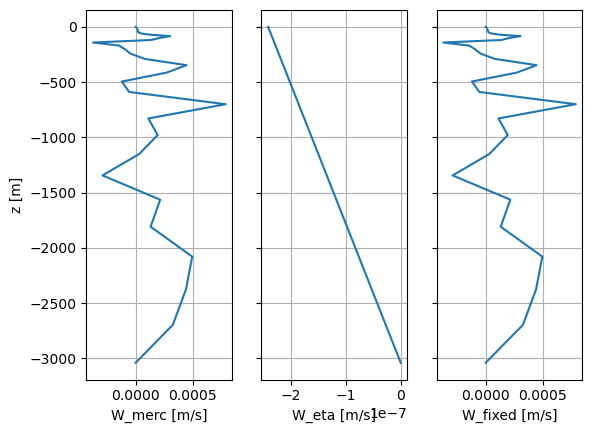

In [22]:
fig, ax = plt.subplots(1, 3, sharey=True)

ax[0].plot(_W_merc, _W_merc.index)
ax[0].set_ylabel("z [m]")
ax[0].set_xlabel("W_merc [m/s]")
ax[0].grid()

ax[1].plot(_W_eta, _W_eta.index)
ax[1].set_xlabel("W_eta [m/s]")
ax[1].grid()

ax[2].plot(_W_fixed, _W_fixed.index)
ax[2].set_xlabel("W_fixed [m/s]")
ax[2].grid()

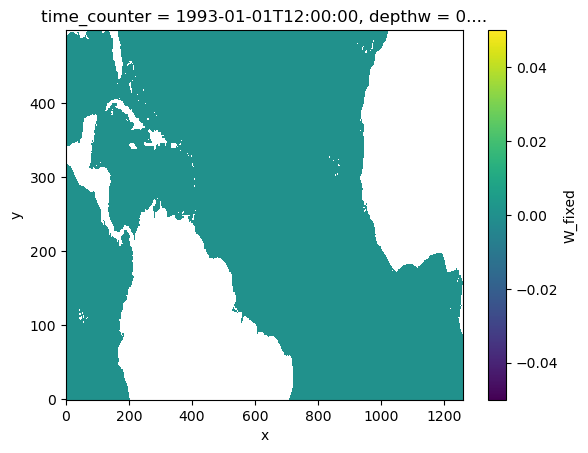

In [24]:
W_fixed.isel(depthw=0).isel(time_counter=0).plot()